# Bab 2 — Fundamental Concepts: How Do Machines Learn?

Notebook ini merangkum **Bab 2** buku *Grokking Deep Learning* (Andrew W. Trask, 2019).

> *"Machine learning will cause every successful IPO win in five years."* — Eric Schmidt, 2016

Bab ini memetakan "lanskap" machine learning: apa itu deep learning, machine learning, dan AI, lalu bagaimana semua algoritma bisa dikelompokkan berdasarkan dua sumbu: **supervised vs unsupervised** (jenis pola yang dipelajari) dan **parametric vs nonparametric** (cara pengetahuan disimpan). Setiap konsep disertai implementasi kecil dengan NumPy.

Isi notebook:
1. Apa itu deep learning?
2. Apa itu machine learning?
3. Supervised machine learning
4. Unsupervised machine learning
5. Parametric vs nonparametric learning
6. Supervised parametric learning — *predict, compare, learn*
7. Unsupervised parametric learning
8. Nonparametric learning
9. Empat kategori algoritma

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from collections import Counter, defaultdict

%matplotlib inline
np.random.seed(0)

## 1. Apa Itu Deep Learning?

**Deep learning adalah subset dari metode machine learning.** Machine learning sendiri adalah bidang yang mempelajari dan mengembangkan mesin yang bisa belajar (kadang dengan tujuan akhir mencapai *general artificial intelligence*).

Di industri, deep learning dipakai untuk tugas praktis seperti:
- **Computer vision** (gambar)
- **Natural language processing** (teks)
- **Automatic speech recognition** (audio)

Deep learning terutama memakai **artificial neural network** — kelas algoritma yang terinspirasi (secara longgar) oleh otak manusia. Disebut *deep* karena jaringannya tersusun atas **banyak layer** yang ditumpuk.

Perhatikan: tidak semua deep learning ditujukan untuk AI umum (mesin yang "sadar" seperti di film). Sebagian besar penerapannya adalah menyelesaikan masalah praktis di industri.

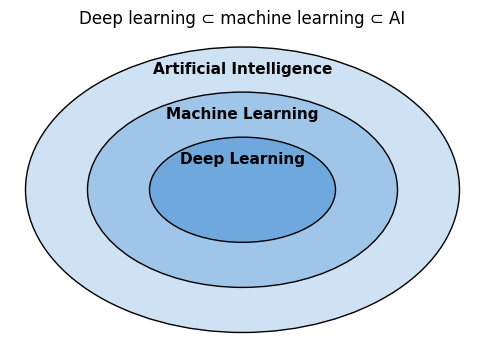

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
for (w, h, label, color, y) in [(5.6, 3.8, 'Artificial Intelligence', '#cfe2f3', 1.6),
                                (4.0, 2.6, 'Machine Learning', '#9fc5e8', 1.05),
                                (2.4, 1.4, 'Deep Learning', '#6fa8dc', 0.0)]:
    ax.add_patch(Ellipse((0, -0.6), w, h, fc=color, ec='k'))
    ax.text(0, -0.6 + h / 2 - 0.35, label, ha='center', fontsize=11, weight='bold')
ax.set_xlim(-3, 3); ax.set_ylim(-2.6, 1.5); ax.axis('off')
ax.set_title('Deep learning ⊂ machine learning ⊂ AI')
plt.show()

## 2. Apa Itu Machine Learning?

> *"A field of study that gives computers the ability to learn without being explicitly programmed."* — Arthur Samuel

Machine learning adalah subbidang ilmu komputer di mana mesin belajar melakukan tugas **tanpa diprogram secara eksplisit**. Mesin **mengamati sebuah pola lalu menirunya**, baik secara langsung maupun tidak langsung:

$$\text{Machine learning} \approx \text{monkey see, monkey do}$$

- **Peniruan langsung** → *supervised learning*
- **Peniruan tidak langsung** → *unsupervised learning*

Bandingkan dua cara membuat program "kalikan angka dengan 2" (salah satu contoh dari buku: *using an input number to predict a number double its size*):

In [3]:
# Cara 1: diprogram eksplisit — kita menulis aturannya sendiri
def double_explicit(x):
    return 2 * x

# Cara 2: machine learning — mesin hanya diberi CONTOH, lalu mencari aturannya sendiri
X = np.array([1.0, 2.0, 3.0, 5.0, 8.0])
Y = np.array([2.0, 4.0, 6.0, 10.0, 16.0])

weight = 0.0                    # mesin belum tahu apa-apa
for _ in range(50):
    for x, y in zip(X, Y):
        pred = x * weight
        weight -= 0.01 * (pred - y) * x   # perbaiki bobot (dibahas di Bab 4)

print(f'Bobot yang dipelajari: {weight:.4f}  (aturan sebenarnya: 2)')
print('Prediksi untuk 7  :', round(7 * weight, 3), '| eksplisit:', double_explicit(7))

Bobot yang dipelajari: 2.0000  (aturan sebenarnya: 2)
Prediksi untuk 7  : 14.0 | eksplisit: 14


Mesin menemukan sendiri bahwa aturannya adalah "kalikan 2", hanya dari contoh. Inilah inti machine learning.

## 3. Supervised Machine Learning

**Supervised learning mentransformasi satu dataset menjadi dataset lain** — dari **apa yang kita ketahui** menjadi **apa yang ingin kita ketahui**.

```
[What you know]  -->  Supervised learning  -->  [What you want to know]
```

Contoh dari buku (input → output):

| Input (yang diketahui) | Output (yang ingin diketahui) |
|---|---|
| Piksel sebuah gambar | Ada kucing atau tidak |
| Film yang kita sukai | Film lain yang mungkin kita sukai |
| Kata-kata seseorang | Apakah ia senang atau sedih |
| Data sensor cuaca | Peluang hujan |
| Sensor mesin mobil | Setelan tuning optimal |
| Berita | Harga saham besok |
| Sebuah angka | Angka dua kali lipatnya |
| File audio | Transkrip audio |

Supervised learning adalah *"bread and butter"* AI terapan (*narrow AI*). Sebagian besar pekerjaan machine learning menghasilkan **supervised classifier**; bahkan unsupervised learning biasanya dipakai untuk membantu membangun supervised model yang lebih akurat.

### Contoh: Monday stock prices → Tuesday stock prices
Jika kita punya 10 tahun data harga saham setiap Senin dan Selasa, algoritma supervised bisa belajar memprediksi harga Selasa dari harga Senin. Mari simulasikan dengan data sintetis:

Model: tuesday ≈ 0.9960 * monday + 0.568
Rata-rata kesalahan prediksi pada tahun terakhir: 0.546


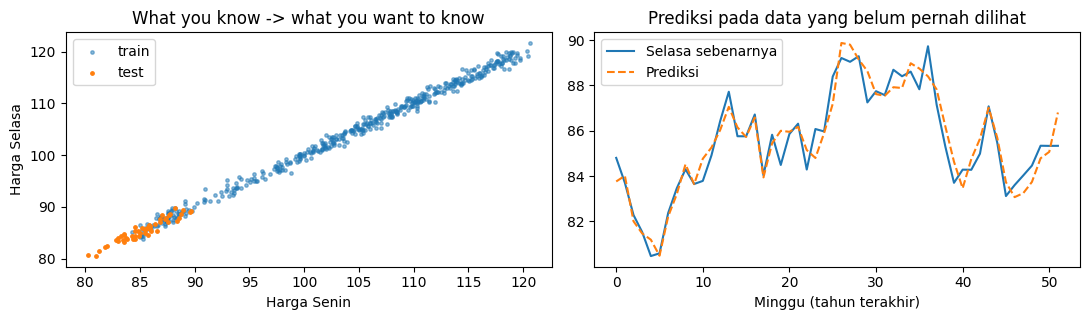

In [4]:
n_weeks = 520   # ±10 tahun
monday = 100 + np.cumsum(np.random.randn(n_weeks))           # harga Senin (random walk)
tuesday = 1.002 * monday + np.random.randn(n_weeks) * 0.8     # Selasa bergantung pada Senin + noise

# Latih pada 9 tahun pertama, uji pada tahun terakhir
train, test = slice(0, 468), slice(468, None)
a, b = np.polyfit(monday[train], tuesday[train], 1)
pred = a * monday[test] + b
mae = np.abs(pred - tuesday[test]).mean()
print(f'Model: tuesday ≈ {a:.4f} * monday + {b:.3f}')
print(f'Rata-rata kesalahan prediksi pada tahun terakhir: {mae:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
axes[0].scatter(monday[train], tuesday[train], s=6, alpha=0.5, label='train')
axes[0].scatter(monday[test], tuesday[test], s=6, color='C1', label='test')
axes[0].set_xlabel('Harga Senin'); axes[0].set_ylabel('Harga Selasa'); axes[0].legend()
axes[0].set_title('What you know -> what you want to know')
axes[1].plot(tuesday[test], label='Selasa sebenarnya')
axes[1].plot(pred, '--', label='Prediksi')
axes[1].set_xlabel('Minggu (tahun terakhir)'); axes[1].legend()
axes[1].set_title('Prediksi pada data yang belum pernah dilihat')
plt.tight_layout(); plt.show()

## 4. Unsupervised Machine Learning

**Unsupervised learning mengelompokkan data.** Ia juga mentransformasi satu dataset menjadi dataset lain, tetapi dataset hasilnya **belum diketahui sebelumnya** — tidak ada "jawaban benar" yang ditiru. Kita hanya berkata: *"temukan pola di data ini dan beri tahu saya."*

```
[List of datapoints]  -->  Unsupervised learning  -->  [List of cluster labels]
```

Bentuk paling umum: **clustering**. Labelnya hanya berupa angka (1, 2, 3, ...) karena algoritma tidak tahu *nama* kelompoknya: *"Hey scientist! I found some structure. It looks like there are groups in your data. Here they are!"*

Menurut Trask, **semua bentuk unsupervised learning bisa dipandang sebagai bentuk clustering**.

### Contoh dari buku: puppies, pizza, kittens, hot dog, burger
Kita beri setiap kata dua fitur sederhana (seberapa *lucu*, seberapa *enak dimakan*), lalu biarkan algoritma k-means mengelompokkan tanpa label:

In [5]:
words = ['puppies', 'pizza', 'kittens', 'hot dog', 'burger']
#                 lucu  enak
features = np.array([[0.95, 0.05],
                     [0.10, 0.90],
                     [0.90, 0.10],
                     [0.05, 0.85],
                     [0.15, 0.95]])

def kmeans(X, k, iters=10, seed=0):
    rng = np.random.default_rng(seed)
    centers = X[rng.choice(len(X), k, replace=False)]
    for _ in range(iters):
        labels = np.argmin(((X[:, None, :] - centers) ** 2).sum(-1), axis=1)
        centers = np.array([X[labels == j].mean(0) for j in range(k)])
    return labels, centers

labels, _ = kmeans(features, 2, seed=1)
for w, l in zip(words, labels):
    print(f'{w:8s} -> cluster {l + 1}')
print('\nAlgoritma tidak tahu nama clusternya. Kita yang menafsirkan: satu cluster = "cute", satu lagi = "delicious".')

puppies  -> cluster 2
pizza    -> cluster 1
kittens  -> cluster 2
hot dog  -> cluster 1
burger   -> cluster 1

Algoritma tidak tahu nama clusternya. Kita yang menafsirkan: satu cluster = "cute", satu lagi = "delicious".


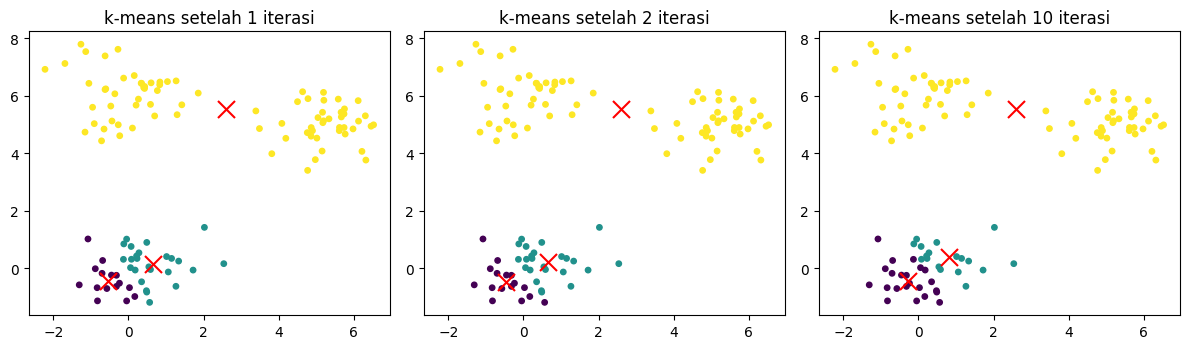

In [6]:
# Clustering pada data 2D: k-means menemukan 3 kelompok tersembunyi, langkah demi langkah
pts = np.vstack([np.random.randn(40, 2) * 0.8 + c for c in ([0, 0], [5, 5], [0, 6])])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, iters in zip(axes, [1, 2, 10]):
    lab, cen = kmeans(pts, 3, iters=iters, seed=3)
    ax.scatter(pts[:, 0], pts[:, 1], c=lab, cmap='viridis', s=15)
    ax.scatter(cen[:, 0], cen[:, 1], marker='x', s=150, c='red')
    ax.set_title(f'k-means setelah {iters} iterasi')
plt.tight_layout(); plt.show()

## 5. Parametric vs Nonparametric Learning

*Oversimplified: trial-and-error learning vs counting and probability.*

Sumbu kedua untuk mengelompokkan algoritma adalah **cara pengetahuan disimpan** (dan, sebagai konsekuensinya, cara belajar):

> **Parametric model** memiliki jumlah parameter yang **tetap**, sedangkan jumlah parameter **nonparametric model** "tak hingga" (**ditentukan oleh data**).

**Analogi pasak persegi:** bayi mencoba memasukkan pasak persegi ke semua lubang sampai ada yang pas (*parametric — trial and error*). Remaja menghitung jumlah sisi pasak (empat) lalu mencari lubang dengan jumlah sisi yang sama (*nonparametric — counting*).

| | **Parametric** | **Nonparametric** |
|---|---|---|
| Jumlah parameter | **Tetap**, dipilih oleh ilmuwan | **Tumbuh** sesuai data |
| Cara belajar (umumnya) | *Trial and error* — memutar kenop | *Counting* — menghitung frekuensi |
| Contoh | Linear regression, **neural network** | Counting, k-NN, decision tree |

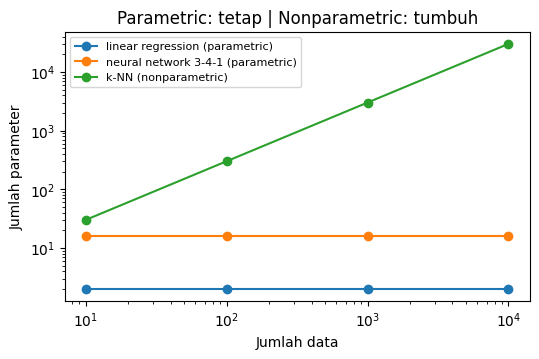

In [7]:
# Jumlah parameter seiring bertambahnya data
n_data = np.array([10, 100, 1_000, 10_000])
params_linear = np.full_like(n_data, 2)          # y = a*x + b -> selalu 2 parameter
params_nn = np.full_like(n_data, 3 * 4 + 4 * 1)  # network 3-4-1 -> selalu 16 bobot
params_knn = n_data * 3                          # k-NN menyimpan seluruh data (3 fitur per contoh)

plt.figure(figsize=(6, 3.5))
plt.loglog(n_data, params_linear, 'o-', label='linear regression (parametric)')
plt.loglog(n_data, params_nn, 'o-', label='neural network 3-4-1 (parametric)')
plt.loglog(n_data, params_knn, 'o-', label='k-NN (nonparametric)')
plt.xlabel('Jumlah data'); plt.ylabel('Jumlah parameter'); plt.legend(fontsize=8)
plt.title('Parametric: tetap | Nonparametric: tumbuh')
plt.show()

## 6. Supervised Parametric Learning

*Oversimplified: trial-and-error learning using knobs.*

Mesin supervised parametric memiliki **sejumlah kenop (knob) yang tetap**. Data masuk, diproses sesuai posisi kenop, lalu diubah menjadi prediksi. **Belajar = memutar kenop** ke sudut yang berbeda. Seluruh pengetahuan model tersimpan pada **posisi kenop** saat itu — sehingga belajar bisa dipandang sebagai **pencarian** konfigurasi kenop yang tepat.

Contoh dari buku: memprediksi apakah **Red Sox** memenangkan World Series. Prosesnya tiga langkah:

| Langkah | Contoh |
|---|---|
| **1. Predict** | Data (lokasi: away, lawan: Yankees, #toes: 250, #players: 25, #fans: 25.000) → mesin → **98%** menang |
| **2. Compare to the truth pattern** | Ternyata kalah: **Pred 98% > Truth 0%** |
| **3. Learn the pattern** | Putar kenop berdasarkan **seberapa jauh meleset** dan **apa inputnya**, agar lain kali prediksinya lebih rendah |

Setiap kenop merepresentasikan **sensitivitas prediksi terhadap satu jenis input**. Misalnya kenop *win/loss record* diputar naik jika ia prediktor yang baik, dan kenop *#toes* diputar turun jika tidak. Inilah yang berubah saat model "belajar".

Mari bangun mesin kenop kecil tersebut:

In [8]:
feature_names = ['home? (1=home)', 'win/loss record', '#toes / 100', '#fans / 10k']

def predict(x, knobs):
    z = x.dot(knobs)
    return 1 / (1 + np.exp(-z))          # ubah ke peluang 0..1

knobs = np.array([1.0, 1.5, 0.8, 0.4])   # posisi kenop awal (sembarang)

# Step 1: Predict
game = np.array([0.0, 0.6, 2.50, 2.5])   # away, record 0.6, 250 toes, 25k fans
pred = predict(game, knobs)
print(f'Step 1 - Predict : peluang menang = {pred:.0%}')

# Step 2: Compare
truth = 0.0                               # Red Sox kalah
print(f'Step 2 - Compare : pred {pred:.0%} vs truth {truth:.0%} -> meleset {pred - truth:+.2f}')

# Step 3: Learn — putar setiap kenop sebanding dengan kesalahan x inputnya
alpha = 0.5
knob_turns = -alpha * (pred - truth) * game
knobs_new = knobs + knob_turns
print('Step 3 - Learn   :')
for name, k_old, turn, k_new in zip(feature_names, knobs, knob_turns, knobs_new):
    print(f'   {name:17s} {k_old:5.2f} -> {k_new:5.2f}  (putar {turn:+.3f})')
print(f'\nPrediksi untuk data yang sama setelah belajar: {predict(game, knobs_new):.0%}')

Step 1 - Predict : peluang menang = 98%
Step 2 - Compare : pred 98% vs truth 0% -> meleset +0.98
Step 3 - Learn   :
   home? (1=home)     1.00 ->  1.00  (putar -0.000)
   win/loss record    1.50 ->  1.21  (putar -0.294)
   #toes / 100        0.80 -> -0.43  (putar -1.225)
   #fans / 10k        0.40 -> -0.83  (putar -1.225)

Prediksi untuk data yang sama setelah belajar: 8%


Perhatikan: kenop **home?** tidak diputar sama sekali karena inputnya 0 (pertandingan *away*) — kenop yang tidak berkontribusi pada prediksi tidak disalahkan. Ide ini akan muncul lagi secara formal di Bab 4.

Sekarang ulangi tiga langkah tersebut untuk **banyak pertandingan** (data sintetis di mana *win/loss record* adalah prediktor yang kuat dan *#toes* tidak berguna):

Akurasi setelah training: 83.50%


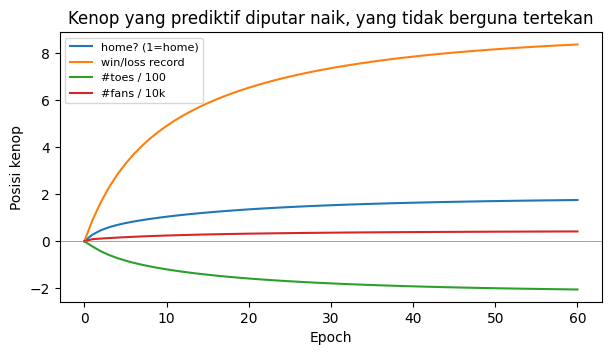

In [9]:
n_games = 200
X = np.column_stack([np.random.randint(0, 2, n_games),          # home?
                     np.random.rand(n_games),                    # win/loss record
                     np.random.uniform(2.3, 2.7, n_games),       # #toes / 100 (tidak berguna)
                     np.random.uniform(1, 5, n_games)])          # #fans / 10k
logit = 1.0 * X[:, 0] + 6 * (X[:, 1] - 0.5) + 0.3 * (X[:, 3] - 3)
Y = (np.random.rand(n_games) < 1 / (1 + np.exp(-logit))).astype(float)

knobs = np.zeros(4)
history = [knobs.copy()]
for epoch in range(60):
    for x, y in zip(X, Y):
        knobs -= 0.05 * (predict(x, knobs) - y) * x      # predict, compare, learn
    history.append(knobs.copy())
history = np.array(history)

acc = ((predict(X, knobs) > 0.5) == Y).mean()
print(f'Akurasi setelah training: {acc:.2%}')
plt.figure(figsize=(7, 3.5))
for i, name in enumerate(feature_names):
    plt.plot(history[:, i], label=name)
plt.axhline(0, color='gray', lw=0.5)
plt.xlabel('Epoch'); plt.ylabel('Posisi kenop'); plt.legend(fontsize=8)
plt.title('Kenop yang prediktif diputar naik, yang tidak berguna tertekan')
plt.show()

## 7. Unsupervised Parametric Learning

Pendekatannya sangat mirip, tetapi tujuannya **mengelompokkan** data. Biasanya ada **beberapa kenop untuk setiap kelompok**, masing-masing memetakan **afinitas** input terhadap kelompok tersebut. Setiap "mesin kelompok" mengubah input menjadi angka 0–1: **peluang input menjadi anggota kelompok itu**.

Contoh dari buku — data pertandingan (home/away, #fans) yang ingin dibagi menjadi 3 kelompok:

| home/away | #fans |
|---|---|
| home | 100k |
| away | 50k |
| home | 100k |
| home | 99k |
| away | 50k |
| away | 10k |
| away | 11k |

Datapoint pertama (home, 100k) dipetakan paling kuat ke group 1 (buku: **94%**, group 2: 1%, group 3: 5%). Kita implementasikan dengan **soft k-means**: setiap kelompok punya kenop berupa titik pusat, dan peluang keanggotaan dihitung dari jarak ke setiap pusat.

In [10]:
data = np.array([[1, 100], [0, 50], [1, 100], [1, 99], [0, 50], [0, 10], [0, 11]], dtype=float)
data_scaled = data / np.array([1, 50])        # samakan skala home/away dan #fans

def membership(x, centers, beta=4.0):
    d = ((x[:, None, :] - centers) ** 2).sum(-1)
    e = np.exp(-beta * d)
    return e / e.sum(1, keepdims=True)         # peluang keanggotaan tiap kelompok

centers = data_scaled[[0, 1, 5]] + np.random.randn(3, 2) * 0.3   # kenop awal: 3 pusat kelompok
for _ in range(20):                            # belajar: geser pusat ke rata-rata berbobot anggotanya
    p = membership(data_scaled, centers)
    centers = (p.T @ data_scaled) / p.sum(0)[:, None]

p = membership(data_scaled, centers)
print('Peluang keanggotaan (group 1, group 2, group 3):')
for (home, fans), row in zip(data, p):
    print(f"  {'home' if home else 'away'} {fans:5.0f}k  ->  " + '  '.join(f'{v:5.0%}' for v in row))

Peluang keanggotaan (group 1, group 2, group 3):
  home   100k  ->   100%     0%     0%
  away    50k  ->     0%    85%    15%
  home   100k  ->   100%     0%     0%
  home    99k  ->   100%     0%     0%
  away    50k  ->     0%    85%    15%
  away    10k  ->     0%    14%    86%
  away    11k  ->     0%    15%    85%


Model menemukan tiga kelompok: *home dengan banyak fans*, *away dengan fans menengah*, dan *away dengan sedikit fans* — tanpa pernah diberi label. Jumlah kenopnya tetap (3 kelompok × 2 dimensi) berapa pun banyaknya data → **parametric**.

## 8. Nonparametric Learning

*Oversimplified: counting-based methods.*

Pada nonparametric learning, jumlah parameter **ditentukan oleh data**. Metodenya umumnya **menghitung**, sehingga jumlah parameter bertambah sesuai jumlah hal yang dihitung.

Contoh dari buku: menghitung berapa kali setiap lampu lalu lintas yang menyala membuat mobil **jalan (go)**. Setelah beberapa contoh, model menyimpulkan lampu tengah **selalu (100%)** membuat mobil jalan, dan lampu kanan hanya **kadang-kadang (50%)**.

In [11]:
# Pengamatan: lampu (kiri, tengah, kanan) yang menyala dan apakah mobil jalan
lights = np.array([[1, 0, 1],
                   [0, 1, 1],
                   [0, 0, 1],
                   [1, 1, 1]])
go = np.array([0, 1, 0, 1])

def count_model(lights, go):
    params = {}
    for i, name in enumerate(['kiri', 'tengah', 'kanan'][:lights.shape[1]] +
                             [f'lampu{j}' for j in range(3, lights.shape[1])]):
        on = lights[:, i] == 1
        params[name] = go[on].mean() if on.any() else float('nan')
    return params

for name, p in count_model(lights, go).items():
    print(f'P(go | lampu {name:6s} menyala) = {p:.0%}')

P(go | lampu kiri   menyala) = 50%
P(go | lampu tengah menyala) = 100%
P(go | lampu kanan  menyala) = 50%


In [12]:
# Jika ada 5 lampu, model otomatis punya 5 "parameter" (counter) — jumlahnya ditentukan data
lights5 = np.random.randint(0, 2, (50, 5))
go5 = lights5[:, 1]                        # pola sebenarnya: lampu ke-1 menentukan
params5 = count_model(lights5, go5)
print('Jumlah parameter dengan 3 lampu:', len(count_model(lights, go)))
print('Jumlah parameter dengan 5 lampu:', len(params5))
print({k: round(float(v), 2) for k, v in params5.items()})

Jumlah parameter dengan 3 lampu: 3
Jumlah parameter dengan 5 lampu: 5
{'kiri': 0.45, 'tengah': 1.0, 'kanan': 0.35, 'lampu3': 0.5, 'lampu4': 0.58}


### k-Nearest Neighbors: nonparametric yang menyimpan seluruh data
k-NN tidak memutar kenop apa pun — "parameternya" adalah **seluruh data training**. Prediksi dibuat dengan melihat tetangga terdekat.

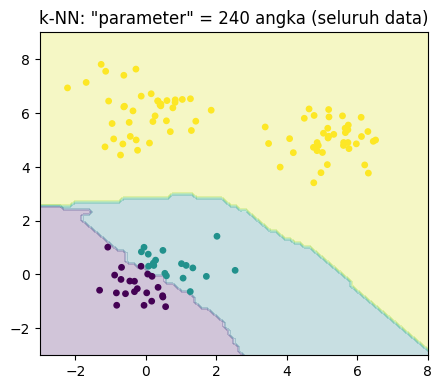

In [13]:
labels_pts, _ = kmeans(pts, 3, seed=3)

def knn_predict(x, X_train, y_train, k=5):
    dist = np.linalg.norm(X_train - x, axis=1)
    nearest = np.argsort(dist)[:k]
    return np.bincount(y_train[nearest]).argmax()

xx, yy = np.meshgrid(np.linspace(-3, 8, 80), np.linspace(-3, 9, 80))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = np.array([knn_predict(g, pts, labels_pts) for g in grid]).reshape(xx.shape)

plt.figure(figsize=(5, 4.2))
plt.contourf(xx, yy, zz, alpha=0.25, cmap='viridis')
plt.scatter(pts[:, 0], pts[:, 1], c=labels_pts, cmap='viridis', s=15)
plt.title(f'k-NN: "parameter" = {pts.size} angka (seluruh data)')
plt.show()

### Wilayah abu-abu
Model parametric dari bagian 6 juga punya satu kenop **per jenis input**, sehingga jumlah parameternya tetap dipengaruhi jumlah fitur/kelas di data. Jadi batas parametric vs nonparametric tidak selalu tegas.

Istilah **parameter** sebenarnya generik: himpunan angka yang dipakai untuk memodelkan sebuah pola — *counts* adalah parameter, *weights* adalah parameter, versi ternormalisasinya juga, bahkan koefisien korelasi. **Deep learning adalah kelas model parametric**; buku ini tidak membahas model nonparametric lebih jauh.

## 9. Empat Kategori Algoritma

Setiap algoritma machine learning adalah **supervised atau unsupervised**, dan **parametric atau nonparametric**:

| | **Parametric** | **Nonparametric** |
|---|---|---|
| **Supervised** | Linear/logistic regression, **neural network** | k-NN, decision tree, counting |
| **Unsupervised** | k-means, Gaussian mixture, **autoencoder** | Hierarchical clustering, DBSCAN |

Neural network di buku ini berada di baris **parametric** — baik untuk supervised maupun unsupervised learning.

## Latihan

1. Pada contoh Red Sox, apa yang terjadi pada kenop jika tim ternyata **menang** (truth = 1)? Hitung arah putaran setiap kenop.
2. Tambahkan lampu keempat yang **selalu menyala** pada model counting. Berapa peluang `go` untuk lampu tersebut, dan mengapa ia tidak informatif?

### Contoh solusi

In [14]:
# Latihan 1
knobs0 = np.array([1.0, 1.5, 0.8, 0.4])
pred = predict(game, knobs0)
turns = -0.5 * (pred - 1.0) * game
print('Putaran kenop jika menang:', {n: round(float(t), 3) for n, t in zip(feature_names, turns)})
print('-> semua kenop dengan input > 0 diputar NAIK (prediksi 98% masih kurang dari 100%)')

# Latihan 2
lights4 = np.column_stack([lights, np.ones(len(lights), dtype=int)])
p4 = count_model(lights4, go)
print('\nP(go | lampu ke-4 menyala) =', p4['lampu3'],
      '-> sama dengan rata-rata go keseluruhan, tidak membedakan apa pun')

Putaran kenop jika menang: {'home? (1=home)': 0.0, 'win/loss record': 0.006, '#toes / 100': 0.025, '#fans / 10k': 0.025}
-> semua kenop dengan input > 0 diputar NAIK (prediksi 98% masih kurang dari 100%)

P(go | lampu ke-4 menyala) = 0.5 -> sama dengan rata-rata go keseluruhan, tidak membedakan apa pun


## Rangkuman Bab 2

- **Deep learning** ⊂ **machine learning** ⊂ **AI**; deep learning memakai neural network berlapis untuk vision, teks, dan audio.
- **Machine learning** = mesin belajar meniru pola dari contoh tanpa diprogram eksplisit (*monkey see, monkey do*).
- **Supervised**: mentransformasi *apa yang diketahui* menjadi *apa yang ingin diketahui* (peniruan langsung). **Unsupervised**: mengelompokkan data tanpa label (clustering).
- **Parametric**: jumlah parameter tetap, belajar dengan *trial and error* memutar kenop. **Nonparametric**: parameter ditentukan data, biasanya dengan *counting*.
- Supervised parametric learning berjalan dalam tiga langkah: **predict → compare to the truth → learn the pattern**; setiap kenop = sensitivitas prediksi terhadap satu input.
- Unsupervised parametric learning memakai kenop per kelompok untuk menghasilkan **peluang keanggotaan**.
- Deep learning adalah **parametric learning** — fondasi semua bab berikutnya.